# **BD MICROCREDITOS 2025**

Se tienen una base de microcreditos en el 2025 para clientes naturales.

In [4]:
pip install flask pandas openpyxl

In [5]:
from flask import Flask, render_template
import pandas as pd

app = Flask(__name__)

@app.route('/')
def index():
    # Leemos el Excel
    df = pd.read_excel('BD_Credit_2025_completo.xlsx')

    # Convertimos el contenido a una tabla HTML
    datos_html = df.to_html(classes='table table-striped', index=False)

    return render_template('index.html', tabla=datos_html)

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [8]:
app.logger.warning("Duplicate route definition for / was removed. Check cell jW1k5yhn_TsE for the active home route.")


**Proyecto Fase 1:** Seleccionar dataset personal, limpieza básica en Pandas, modularizar limpieza en funciones puras (archivo .py separado).

In [9]:
# --- Contenido para limpieza.py ---
import pandas as pd
import numpy as np

def limpiar_datos_credito(df: pd.DataFrame) -> pd.DataFrame:
    """
    Función pura para limpieza básica de BD_Credit_2025
    """
    # 1. Normalizar nombres de columnas
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

    # 2. Manejo de nulos (basado en tu notebook)
    df = df.dropna(subset=['id_credit']) # ID es vital

    # 3. Conversión de tipos
    if 'loandate' in df.columns:
        df['loandate'] = pd.to_datetime(df['loandate'], errors='coerce')

    # 4. Eliminar duplicados
    df = df.drop_duplicates()

    return df

In [10]:
import pandas as pd

def cargar_datos(ruta: str) -> pd.DataFrame:
    return pd.read_excel(ruta)

def normalizar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.lower()
    return df

def convertir_fecha(df: pd.DataFrame) -> pd.DataFrame:
    df["loandate"] = pd.to_datetime(df["loandate"])
    return df

def eliminar_nulos(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna()

def eliminar_duplicados(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates()

def crear_ratio_aprobacion(df: pd.DataFrame) -> pd.DataFrame:
    df["ratio_aprobacion"] = df["cupo_aprobado"] / df["cupo_solicitado"]
    return df

def ejecutar_pipeline() -> None:
    df = cargar_datos("/content/BD_Credit_2025_completo.xlsx")
    df = normalizar_columnas(df)
    df = convertir_fecha(df)
    df = eliminar_nulos(df)
    df = eliminar_duplicados(df)
    df = crear_ratio_aprobacion(df)

    print(df.head())
    print("Dimensión final:", df.shape)

if __name__ == "__main__":
    ejecutar_pipeline()

   id_credit  customer_id   loandate  b_m             city   age  \
0          1      1082423 2016-11-25    1  ATLANTHIC SOUTH  32.0   
1          2      1069232 2020-05-28    1  ATLANTHIC SOUTH  29.0   
2          3      1031705 2016-06-25    1  ATLANTHIC SOUTH  67.0   
3          4      1089806 2018-06-09    0      NEW ENGALND  30.0   
4          5      1076695 2018-01-06    1      NEW ENGALND  62.0   

  time_experience    activity bankingexp otherincome  ...  delincuency_hist  \
0              20    Empleado          N           S  ...                 1   
1              20  Pensionado          S           S  ...                 0   
2              20    Empleado          S           S  ...                 3   
3              20    Empleado          S           S  ...                 2   
4     30.33333333    Empleado          S           S  ...                 0   

   score_1  score_2  score_3  score_4  cupo_solicitado  cupo_aprobado  \
0      525      560      700      700      

In [ ]:
pip install pydantic


### ANALISIS DESCRIPTIVO

In [ ]:
# Cargar datos
df = pd.read_excel("BD_Credit_2025_completo.xlsx")

In [ ]:
# Normalizar columnas
df.columns = df.columns.str.lower()

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (5197, 22)


,id_credit,customer_id,loandate,b_m,city,age,time_experience,activity,bankingexp,otherincome,...,income,delincuency_hist,score_1,score_2,score_3,score_4,cupo_solicitado,cupo_aprobado,canal_cobranza,resultado_cobranza
0,1,1082423,2016-11-25,1,ATLANTHIC SOUTH,32.0,20,Empleado,N,S,...,1250.0,1,525,560,700,700,28654,25249,Correo,No contactado
1,2,1069232,2020-05-28,1,ATLANTHIC SOUTH,29.0,20,Pensionado,S,S,...,1500.0,0,493,529,590,660,20795,10802,Correo,No contactado
2,3,1031705,2016-06-25,1,ATLANTHIC SOUTH,67.0,20,Empleado,S,S,...,1000.0,3,532,636,617,836,5860,5383,Correo,No contactado
3,4,1089806,2018-06-09,0,NEW ENGALND,30.0,20,Empleado,S,S,...,1600.0,2,776,660,755,686,10390,8413,Ninguno,No aplica
4,5,1076695,2018-01-06,1,NEW ENGALND,62.0,30.33333333,Empleado,S,S,...,1926.0,0,488,549,631,886,26575,20774,SMS,Pago parcial


**2️⃣ Calidad de Datos**

In [ ]:
# Tipos de datos
df.info()

# Valores nulos
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5197 entries, 0 to 5196
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_credit           5197 non-null   int64         
 1   customer_id         5197 non-null   int64         
 2   loandate            5197 non-null   datetime64[ns]
 3   b_m                 5197 non-null   int64         
 4   city                5197 non-null   object        
 5   age                 5196 non-null   float64       
 6   time_experience     5197 non-null   object        
 7   activity            5197 non-null   object        
 8   bankingexp          5197 non-null   object        
 9   otherincome         5197 non-null   object        
 10  sectbalance         5197 non-null   int64         
 11  exp                 5197 non-null   float64       
 12  income              5197 non-null   float64       
 13  delincuency_hist    5197 non-null   int64       

,0
age,1


In [ ]:
# Porcentaje de nulos
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
age,0.019242
id_credit,0.000000
customer_id,0.000000
loandate,0.000000
b_m,0.000000
city,0.000000
time_experience,0.000000
activity,0.000000
bankingexp,0.000000
otherincome,0.000000


In [ ]:
# Duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


📊 3️⃣ Estadística Descriptiva General

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id_credit,5197.0,2599.0,1.0,1300.0,2599.0,3898.0,5197.0,1500.389005
customer_id,5197.0,1049725.743121,1000014.0,1024796.0,1049032.0,1074632.0,1099963.0,28771.920593
loandate,5197,2017-12-05 13:36:17.179141888,2014-03-12 00:00:00,2016-08-05 00:00:00,2017-11-22 00:00:00,2019-04-19 00:00:00,2021-07-13 00:00:00,NaN
b_m,5197.0,0.494516,0.0,0.0,0.0,1.0,1.0,0.500018
age,5196.0,43.739415,18.0,33.0,43.0,54.0,80.0,12.887379
sectbalance,5197.0,7926.47335,825.0,5000.0,7500.0,10000.0,120000.0,4244.234254
exp,5197.0,1108.84864,0.0,310.0,465.0,704.0,512572.0,7565.679317
income,5197.0,2360.103019,200.0,900.0,1200.0,1725.0,129080.0,5368.153349
delincuency_hist,5197.0,1.414277,0.0,0.0,1.0,3.0,4.0,1.488541
score_1,5197.0,601.364056,338.0,501.0,605.0,701.0,896.0,111.430157


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_credit,5197.0,NaN,NaN,NaN,2599.0,1.0,1300.0,2599.0,3898.0,5197.0,1500.389005
customer_id,5197.0,NaN,NaN,NaN,1049725.743121,1000014.0,1024796.0,1049032.0,1074632.0,1099963.0,28771.920593
loandate,5197,NaN,NaN,NaN,2017-12-05 13:36:17.179141888,2014-03-12 00:00:00,2016-08-05 00:00:00,2017-11-22 00:00:00,2019-04-19 00:00:00,2021-07-13 00:00:00,NaN
b_m,5197.0,NaN,NaN,NaN,0.494516,0.0,0.0,0.0,1.0,1.0,0.500018
city,5197,5,NEW YORK,2238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5196.0,NaN,NaN,NaN,43.739415,18.0,33.0,43.0,54.0,80.0,12.887379
time_experience,5197,178,0,2837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity,5197,3,Pensionado,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bankingexp,5197,2,S,3787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
otherincome,5197,2,S,3883,NaN,NaN,NaN,NaN,NaN,NaN,NaN


📈 4️⃣ Análisis por Variables Clave

🎂 Edad

In [ ]:
print("Edad promedio:", df["age"].mean())
print("Edad mínima:", df["age"].min())
print("Edad máxima:", df["age"].max())

Edad promedio: 43.73941493456505
Edad mínima: 18.0
Edad máxima: 80.0


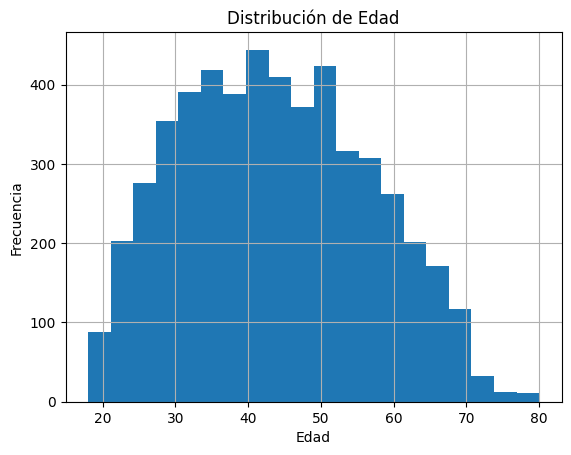

In [ ]:
df["age"].hist(bins=20)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💰 Ingreso

In [ ]:
print("Ingreso promedio:", df["income"].mean())
print("Ingreso mediana:", df["income"].median())

Ingreso promedio: 2360.1030186646144
Ingreso mediana: 1200.0


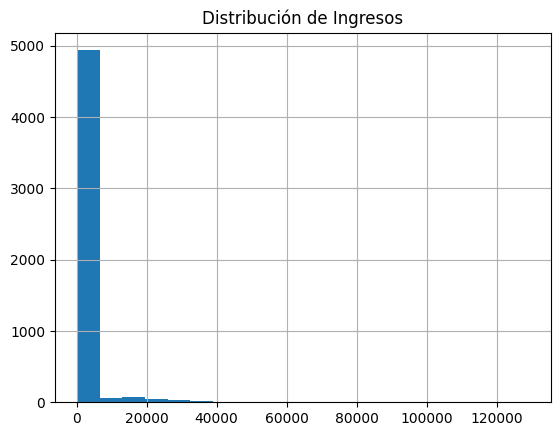

In [ ]:
df["income"].hist(bins=20)
plt.title("Distribución de Ingresos")
plt.show()

💳 5️⃣ Análisis Crediticio

In [ ]:
df["ratio_aprobacion"] = df["cupo_aprobado"] / df["cupo_solicitado"]

print("Ratio promedio:", df["ratio_aprobacion"].mean())

Ratio promedio: 0.746246366122292


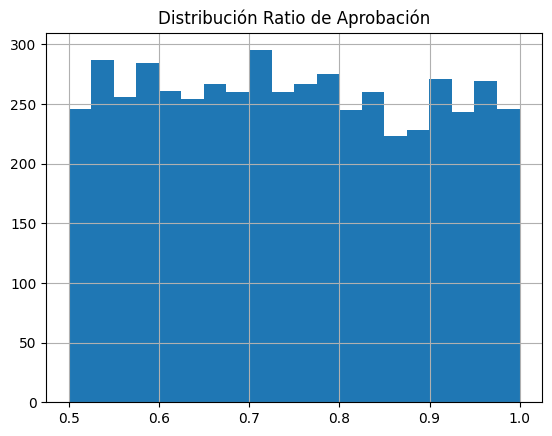

In [ ]:
df["ratio_aprobacion"].hist(bins=20)
plt.title("Distribución Ratio de Aprobación")
plt.show()

**Relación ingreso vs cupo solicitado**

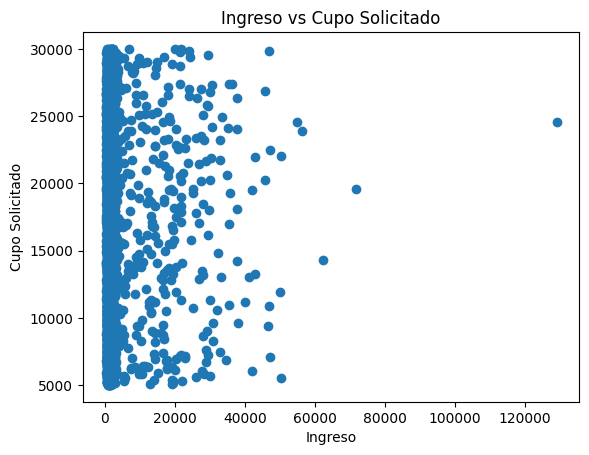

In [ ]:
plt.scatter(df["income"], df["cupo_solicitado"])
plt.xlabel("Ingreso")
plt.ylabel("Cupo Solicitado")
plt.title("Ingreso vs Cupo Solicitado")
plt.show()

**Scores**

In [ ]:
scores = ["score_1", "score_2", "score_3", "score_4"]
df[scores].describe()

,score_1,score_2,score_3,score_4
count,5197.000000,5197.000000,5197.000000,5197.000000
mean,601.364056,629.970560,650.420050,695.937272
std,111.430157,78.702581,70.257993,93.522757
min,338.000000,345.000000,396.000000,323.000000
25%,501.000000,574.000000,604.000000,633.000000
50%,605.000000,631.000000,650.000000,695.000000
75%,701.000000,686.000000,697.000000,760.000000
max,896.000000,869.000000,890.000000,1073.000000


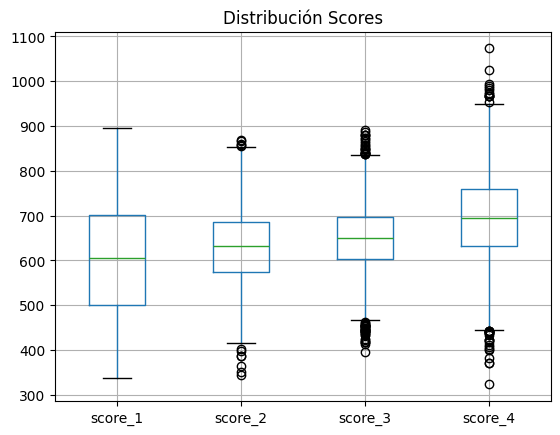

In [ ]:
df[scores].boxplot()
plt.title("Distribución Scores")
plt.show()

🔗 6️⃣ Matriz de Correlación

In [ ]:
corr = df.corr(numeric_only=True)
corr

,id_credit,customer_id,b_m,age,sectbalance,exp,income,delincuency_hist,score_1,score_2,score_3,score_4,cupo_solicitado,cupo_aprobado,ratio_aprobacion
id_credit,1.000000,-0.014481,0.011567,0.008019,-0.018807,-0.013957,-0.012982,0.006688,-0.022487,0.004881,0.013736,-0.016769,-0.007158,-0.008958,-0.008737
customer_id,-0.014481,1.000000,-0.007133,-0.005778,0.001808,0.019823,0.010620,-0.004964,0.019175,0.005719,-0.008946,0.007211,-0.023433,-0.025804,-0.013411
b_m,0.011567,-0.007133,1.000000,-0.013630,0.016763,-0.015575,0.000903,-0.017245,-0.894681,-0.638642,-0.004457,0.258713,0.007607,0.007319,-0.000642
age,0.008019,-0.005778,-0.013630,1.000000,-0.102162,-0.011845,-0.033221,0.011863,0.019771,0.003564,-0.008488,0.004713,-0.008997,-0.013912,-0.011383
sectbalance,-0.018807,0.001808,0.016763,-0.102162,1.000000,0.075346,0.198274,-0.011456,-0.011911,-0.010564,-0.006251,0.005317,0.012654,0.019551,0.018204
exp,-0.013957,0.019823,-0.015575,-0.011845,0.075346,1.000000,0.318911,0.002081,0.018458,0.021525,0.008938,0.001830,-0.018611,-0.011368,0.020942
income,-0.012982,0.010620,0.000903,-0.033221,0.198274,0.318911,1.000000,0.019080,-0.003431,-0.006742,0.006373,-0.006088,-0.004112,0.003802,0.015813
delincuency_hist,0.006688,-0.004964,-0.017245,0.011863,-0.011456,0.002081,0.019080,1.000000,0.000091,0.008528,-0.006232,0.002093,0.010493,0.001896,-0.007536
score_1,-0.022487,0.019175,-0.894681,0.019771,-0.011911,0.018458,-0.003431,0.000091,1.000000,0.566643,-0.002763,-0.234982,-0.021743,-0.023296,-0.010206
score_2,0.004881,0.005719,-0.638642,0.003564,-0.010564,0.021525,-0.006742,0.008528,0.566643,1.000000,-0.002500,-0.180398,-0.002851,-0.002168,-0.000561


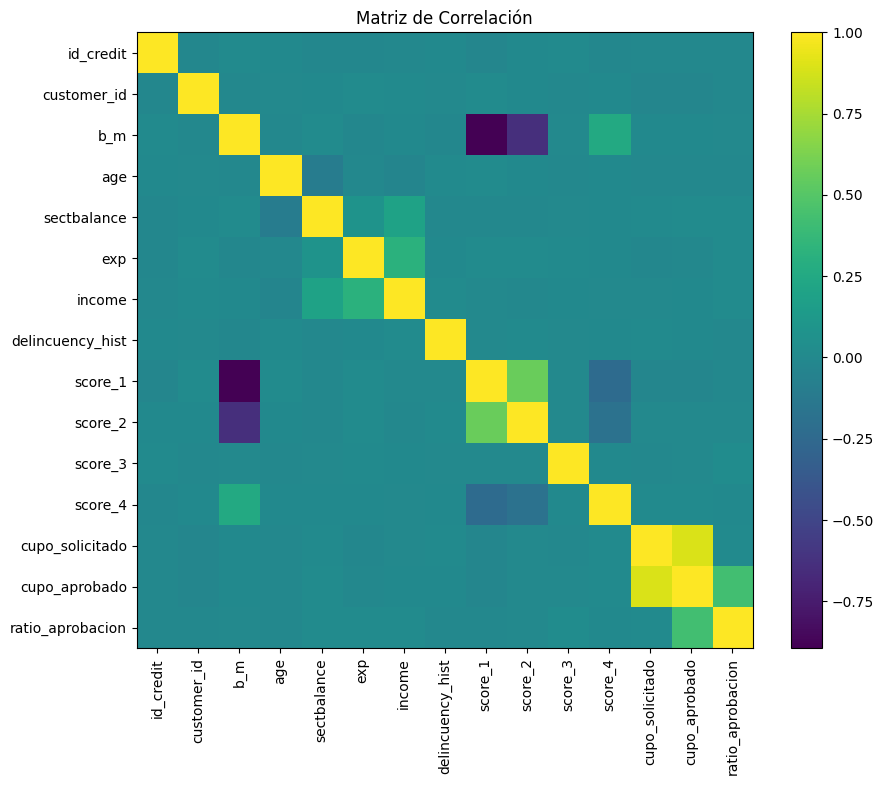

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de Correlación")
plt.show()

📊 7️⃣ Segmentación
Por rangos de edad

In [ ]:
df["grupo_edad"] = pd.cut(df["age"], bins=[18,25,35,50,70])

df.groupby("grupo_edad")["ratio_aprobacion"].mean()

/tmp/ipython-input-2697637672.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("grupo_edad")["ratio_aprobacion"].mean()


,ratio_aprobacion
grupo_edad,
"(18, 25]",0.747160
"(25, 35]",0.743712
"(35, 50]",0.749534
"(50, 70]",0.744071


**Por nivel de ingreso**

In [ ]:
df["grupo_ingreso"] = pd.qcut(df["income"], 4)

df.groupby("grupo_ingreso")["cupo_aprobado"].mean()

/tmp/ipython-input-3508767746.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("grupo_ingreso")["cupo_aprobado"].mean()


,cupo_aprobado
grupo_ingreso,
"(199.999, 900.0]",13073.728643
"(900.0, 1200.0]",13026.345877
"(1200.0, 1725.0]",13077.473726
"(1725.0, 129080.0]",13207.707467


📈 8️⃣ Detección de Outliers

In [ ]:
Q1 = df["income"].quantile(0.25)
Q3 = df["income"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["income"] < Q1 - 1.5*IQR) |
              (df["income"] > Q3 + 1.5*IQR)]

print("Cantidad de outliers en ingreso:", len(outliers))

Cantidad de outliers en ingreso: 385


In [ ]:
print("Coeficiente de variación ingreso:",
      df["income"].std() / df["income"].mean())

Coeficiente de variación ingreso: 2.2745419612623445


In [ ]:
print("Skewness ingreso:", df["income"].skew())
print("Kurtosis ingreso:", df["income"].kurt())

Skewness ingreso: 7.633831785363428
Kurtosis ingreso: 94.02029152364048


# **Crear esquemas Pydantic para el dataset elegido en Fase 1 (InputSchema y OutputSchema).**

In [ ]:
from pydantic import BaseModel, Field
from datetime import datetime


class CreditInputSchema(BaseModel):
    customer_id: int = Field(..., example=1082423)
    loandate: datetime = Field(..., example="2020-05-28")
    age: float = Field(..., gt=18, example=35)
    income: float = Field(..., gt=0, example=1500)
    time_experience: float = Field(..., ge=0, example=5)
    cupo_solicitado: float = Field(..., gt=0, example=20000)
    score_1: int = Field(..., ge=0, le=1000)
    score_2: int = Field(..., ge=0, le=1000)
    score_3: int = Field(..., ge=0, le=1000)
    score_4: int = Field(..., ge=0, le=1000)


class CreditOutputSchema(BaseModel):
    customer_id: int
    cupo_solicitado: float
    cupo_aprobado: float
    ratio_aprobacion: float
    resultado_cobranza: str


/tmp/ipython-input-655666447.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  customer_id: int = Field(..., example=1082423)
/tmp/ipython-input-655666447.py:7: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  loandate: datetime = Field(..., example="2020-05-28")
/tmp/ipython-input-655666447.py:8: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3

In [ ]:
from pydantic import BaseModel, Field
from datetime import datetime


class CreditInputSchema(BaseModel):
    customer_id: int = Field(..., example=1082423)
    loandate: datetime = Field(..., example="2020-05-28")
    age: float = Field(..., gt=18, example=35)
    income: float = Field(..., gt=0, example=1500)
    time_experience: float = Field(..., ge=0, example=5)
    cupo_solicitado: float = Field(..., gt=0, example=20000)
    score_1: int = Field(..., ge=0, le=1000)
    score_2: int = Field(..., ge=0, le=1000)
    score_3: int = Field(..., ge=0, le=1000)
    score_4: int = Field(..., ge=0, le=1000)

data = {
    "customer_id": 1082423,
    "loandate": "2020-05-28",
    "age": 30,
    "income": 2000,
    "time_experience": 5,
    "cupo_solicitado": 15000,
    "score_1": 500,
    "score_2": 600,
    "score_3": 650,
    "score_4": 700
}

credit = CreditInputSchema(**data)
print(credit)

customer_id=1082423 loandate=datetime.datetime(2020, 5, 28, 0, 0) age=30.0 income=2000.0 time_experience=5.0 cupo_solicitado=15000.0 score_1=500 score_2=600 score_3=650 score_4=700


/tmp/ipython-input-29232224.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  customer_id: int = Field(..., example=1082423)
/tmp/ipython-input-29232224.py:7: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  loandate: datetime = Field(..., example="2020-05-28")
/tmp/ipython-input-29232224.py:8: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0.

# SEMANA 3

In [ ]:
from flask import Flask, jsonify, render_template
import pandas as pd
from logic import normalizar_columnas, limpiar_datos, generar_analisis_estadistico
from schemas import CreditOutputSchema
import os # Import os module to handle file existence

app = Flask(__name__)

# Ruta al archivo (Asegúrate que el nombre coincida con el de tu carpeta)
FILE_PATH_XLSX = "/content/BD_Credit_2025_completo.xlsx"
FILE_PATH_CSV = "/content/BD_Credit_2025_completo.csv" # Keep csv for potential future use or if conversion is needed

@app.route('/')
def home():
    """Endpoint para mostrar el análisis descriptivo (Simulación de HTML)."""
    try:
        # Check if the XLSX file exists, otherwise try CSV
        if os.path.exists(FILE_PATH_XLSX):
            df = pd.read_excel(FILE_PATH_XLSX)
        elif os.path.exists(FILE_PATH_CSV):
            df = pd.read_csv(FILE_PATH_CSV)
        else:
            raise FileNotFoundError("Neither BD_Credit_2025_completo.xlsx nor .csv found.")

        df = normalizar_columnas(df)
        df = limpiar_datos(df)
        stats = generar_analisis_estadistico(df)

        return jsonify({
            "titulo": "Análisis Descriptivo Microcréditos 2025",
            "metricas": stats,
            "mensaje": "Este objeto JSON puede ser consumido por tu archivo HTML"
        })
    except Exception as e:
        return jsonify({"error": str(e)})

@app.route('/clean', methods=['GET'])
def clean_data_endpoint():
    """SEMANA 3: Migración de funciones de limpieza a Endpoint."""
    try:
        # 1. Cargar y procesar
        # Check if the XLSX file exists, otherwise try CSV
        if os.path.exists(FILE_PATH_XLSX):
            df = pd.read_excel(FILE_PATH_XLSX)
        elif os.path.exists(FILE_PATH_CSV):
            df = pd.read_csv(FILE_PATH_CSV)
        else:
            raise FileNotFoundError("Neither BD_Credit_2025_completo.xlsx nor .csv found.")

        df = normalizar_columnas(df)
        df = limpiar_datos(df)

        # 2. Seleccionar solo las columnas que coinciden con el OutputSchema
        columnas_salida = ["customer_id", "cupo_solicitado", "cupo_aprobado", "ratio_aprobacion", "resultado_cobranza"]
        # Ensure all required columns exist before selecting
        available_cols = [col for col in columnas_salida if col in df.columns]
        datos_finales = df[available_cols].head(100).to_dict(orient='records')

        # 3. Validar con Pydantic (opcional pero recomendado)
        # Filter out records that might not fully conform to the schema if columns are missing
        valid_data = []
        for item in datos_finales:
            try:
                valid_data.append(CreditOutputSchema(**item).model_dump())
            except Exception as validation_error:
                print(f"Skipping invalid record: {item} due to {validation_error}")

        return jsonify({
            "status": "success",
            "records_cleaned": len(df),
            "sample": valid_data
        })
    except Exception as e:
        return jsonify({"status": "error", "message": str(e)}), 500

if __name__ == "__main__":
    # In a Colab environment, use a different approach to run Flask apps directly
    # For local execution, app.run(debug=True, port=5000) is standard.
    # For Colab, you might use ngrok or a similar tool for public exposure
    # or run it in a way that it can be accessed within Colab.
    # For now, we will not run app.run() to avoid blocking the kernel
    # if the intention is to just define the app and modules.
    print("Flask app defined. Run `app.run()` if you want to start the server.")


Flask app defined. Run `app.run()` if you want to start the server.


In [ ]:
%%writefile logic.py
import pandas as pd
from datetime import datetime

def normalizar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.lower()
    return df

def convertir_fecha(df: pd.DataFrame) -> pd.DataFrame:
    if 'loandate' in df.columns:
        df['loandate'] = pd.to_datetime(df['loandate'], errors='coerce')
    return df

def eliminar_nulos(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna()

def eliminar_duplicados(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates()

def crear_ratio_aprobacion(df: pd.DataFrame) -> pd.DataFrame:
    if "cupo_aprobado" in df.columns and "cupo_solicitado" in df.columns:
        df["ratio_aprobacion"] = df["cupo_aprobado"] / df["cupo_solicitado"].replace(0, pd.NA)
    return df

def limpiar_datos(df: pd.DataFrame) -> pd.DataFrame:
    df = convertir_fecha(df)
    df = eliminar_nulos(df)
    df = eliminar_duplicados(df)
    df = crear_ratio_aprobacion(df)
    return df

def generar_analisis_estadistico(df: pd.DataFrame) -> dict:
    numeric_cols = df.select_dtypes(include=['number']).columns
    if not numeric_cols.empty:
        return df[numeric_cols].describe().to_dict()
    else:
        return {"message": "No numeric columns for statistical analysis."}

Overwriting logic.py


In [ ]:
%%writefile schemas.py
from pydantic import BaseModel, Field
from datetime import datetime


class CreditInputSchema(BaseModel):
    customer_id: int = Field(..., example=1082423)
    loandate: datetime = Field(..., example="2020-05-28")
    age: float = Field(..., gt=18, example=35)
    income: float = Field(..., gt=0, example=1500)
    time_experience: float = Field(..., ge=0, example=5)
    cupo_solicitado: float = Field(..., gt=0, example=20000)
    score_1: int = Field(..., ge=0, le=1000)
    score_2: int = Field(..., ge=0, le=1000)
    score_3: int = Field(..., ge=0, le=1000)
    score_4: int = Field(..., ge=0, le=1000)


class CreditOutputSchema(BaseModel):
    customer_id: int
    cupo_solicitado: float
    cupo_aprobado: float
    ratio_aprobacion: float
    resultado_cobranza: str

Overwriting schemas.py


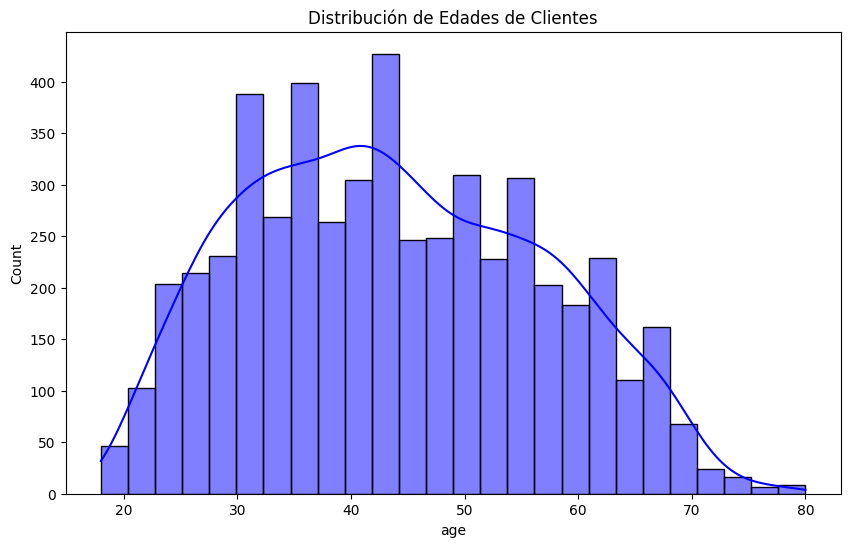

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
from logic import normalizar_columnas, limpiar_datos # Import the necessary functions

# Load the data and process it to define 'df'
FILE_PATH_XLSX = "/content/BD_Credit_2025_completo.xlsx"
df = pd.read_excel(FILE_PATH_XLSX)
df = normalizar_columnas(df)
df = limpiar_datos(df)

# Create the 'static' directory if it doesn't exist
os.makedirs('static', exist_ok=True)

plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Distribución de Edades de Clientes')
plt.savefig('static/distribucion_edad.png')
plt.show() # Display the plot in the output

# Semana 4:Transición a FastAPI

In [ ]:
# --- Contenido para main.py ---
from fastapi import FastAPI, HTTPException
from typing import List
from schemas import CreditInput, CreditOutput
import pandas as pd
from limpieza import limpiar_datos_credito

app = FastAPI(title="API de Créditos 2025")

@app.post("/clean", response_model=List[CreditOutput])
async def clean_data(data: List[CreditInput]):
    # Convertimos lista de Pydantic a DataFrame
    df = pd.DataFrame([item.dict() for item in data])

    # Aplicamos limpieza de Semana 1
    df_cleaned = limpiar_datos_credito(df)

    # Retornamos según el esquema de salida
    return [CreditOutput(id_credit=row['id_credit']) for _, row in df_cleaned.iterrows()]